# Count map from $m_5$

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
import pyccl as ccl

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
from spectra import Spectrum

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## $m_5$ magnitude

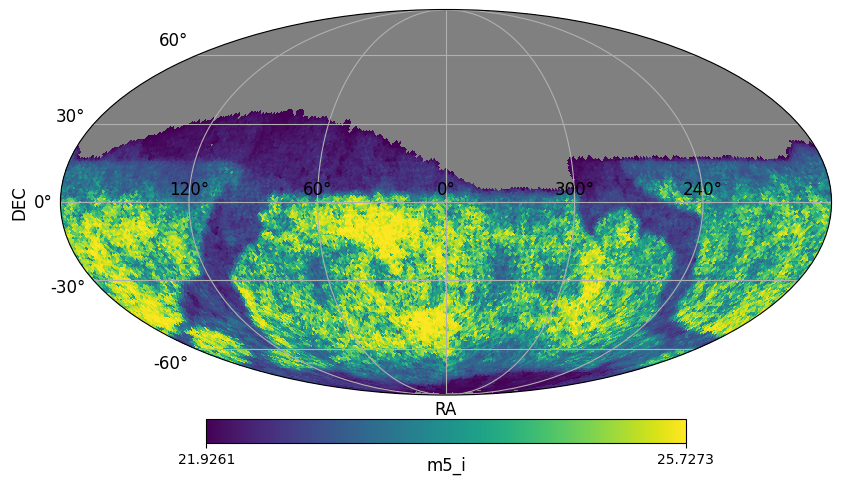

In [3]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 316.7 (χ²/ndof = 0.0)      │              Nfcn = 741              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │            time = 9.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  24.805   │   0.035   │   -0.035   │   0.035    │    0    │         │       │
│ 1 │ A    │  0.0222   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    259    │    25     │    -26     │     25     │    0    │   360   │       │
│ 3 │ dec  │    -79    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0027  │  0.0027   │    -26    │    26     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   0.00124    -59e-6    0.0844    0.0559 │
│   A │    -59e-6   7.3e-06 -5.470e-3 -3.961e-3 │
│  ra │    0.0844 -5.470e-3       625         5 │
│ dec │    0.0559 -3.961e-3         5      24.8 │
└─────┴─────────────────────────────────────────┘

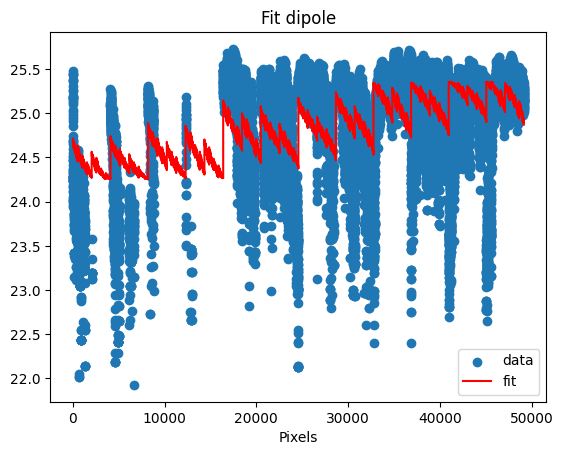

In [4]:
init =  (10, 1, 100, 40)
m = dm.fit_dipole("iMasked", init, plot_map=False)
m

## Ratio determination

In [5]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN


Generating redshifts
Number of rejects = 689466
Accepted ratio = 77%

Generating dL
Generating luminosities
Number of rejects = 684667
Accepted ratio = 77%


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.9499432381269034,6390.55408517547,235117312.31348196,-16.0982115214023,27.929481052411518
0.16195244869948333,804.7629310936788,4587988245.645356,-19.32405574143734,20.204284077289472
0.6726187849415379,4188.685844300704,62536063.58331311,-14.660326351291515,28.450062593982047
0.3889242515703086,2174.9963899998047,268494505.9665426,-16.24233850858218,25.444954193722904
0.15863610024686609,786.701917350362,46203908.45536314,-14.331696786769173,25.147354256396724
0.36077562569478816,1991.8766242320626,478344399.72985196,-16.869351734443896,24.626960440325366
0.7138563049169734,4503.368908045769,1580301646.155946,-18.166849981242613,25.100837644051925
1.3609965008859173,9949.206382853446,2079162219.9915075,-18.464720937733112,26.52422126132542


Saving LumDist in Simul_Figures/Simul_Schechter/Schechter_LumDist.pdf


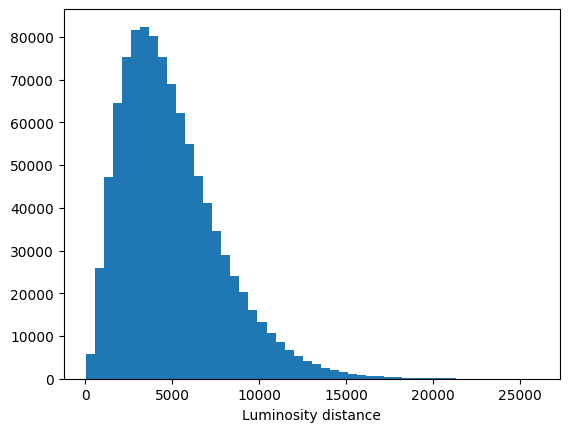

In [6]:
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=50);

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDist")

Saving LumDistLogLog in Simul_Figures/Simul_Schechter/Schechter_LumDistLogLog.pdf


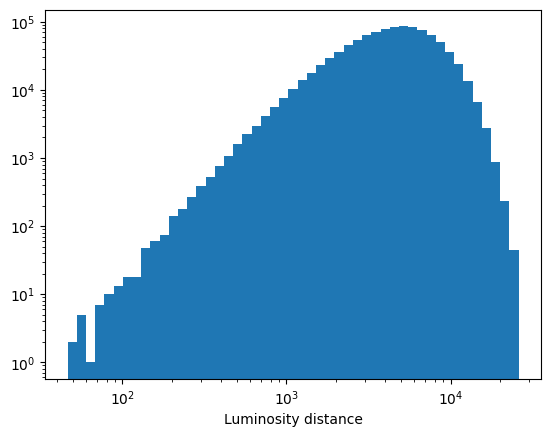

In [7]:
binsdL = np.logspace(np.log10(np.min(dataN["dL"])), np.log10(np.max(dataN["dL"])), 50)
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=binsdL, log=True);
plt.xscale('log')

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDistLogLog")

Saving ApparentMag in Simul_Figures/Simul_Schechter/Schechter_ApparentMag.pdf


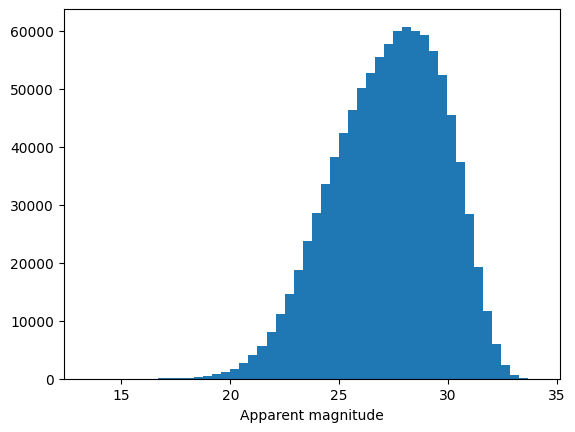

In [8]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$")

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag")

Saving ApparentMag_cut in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_cut.pdf


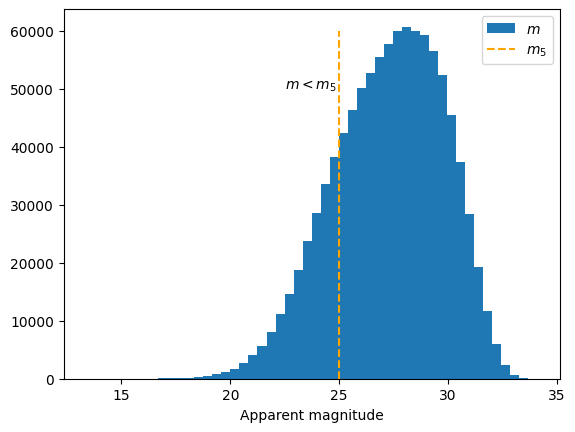

In [9]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$");
plt.vlines(25, 0, 60000, linestyles = 'dashed', colors="orange", label="$m_5$")
plt.text(22.5, 50000, "$m < m_5$")
plt.legend()

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag_cut")

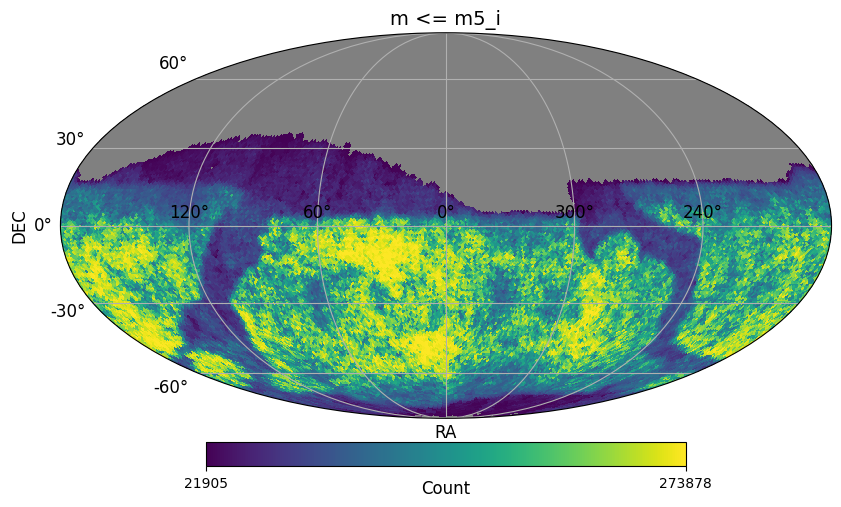

In [10]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= "m <= m5_i")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CountMap_m5band_i")

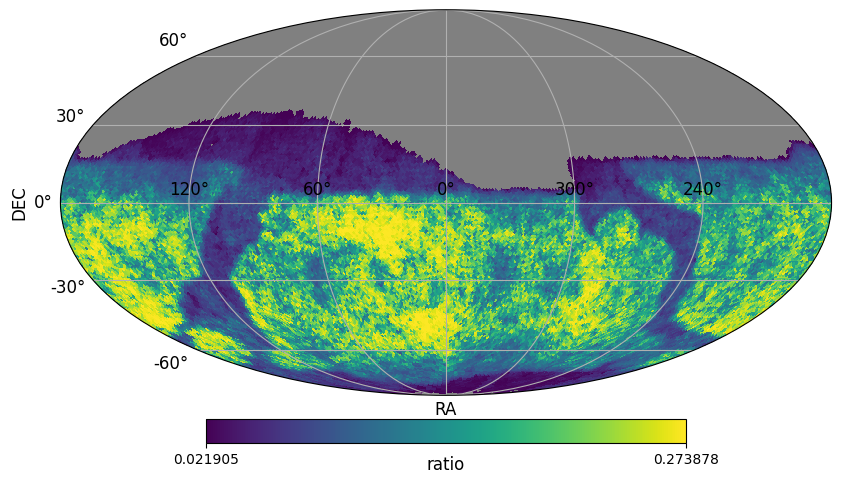

In [11]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "RatioMap_m5band_i")

## Souce sampling

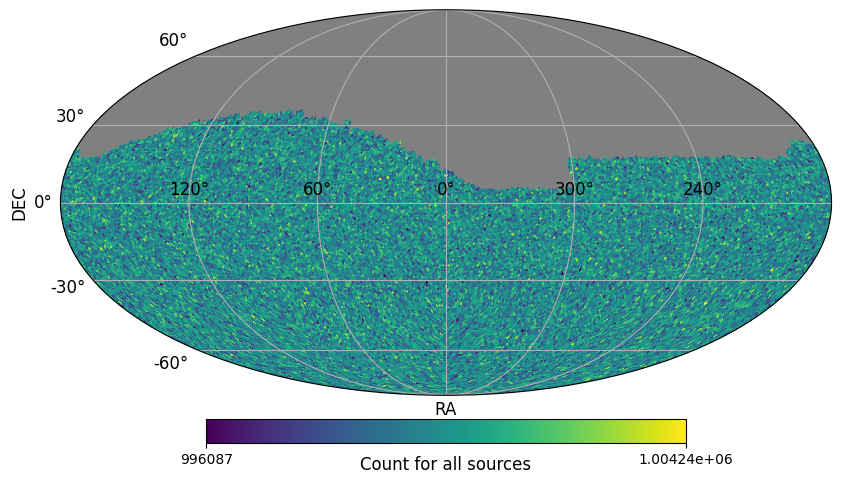

In [12]:
count_thMapper = CountMapper.from_map(np.random.poisson(NSource_px_th, npix))
count_thMapper._set_suffixTextPlot(unit = "all sources")
count_thMapper.set_mask(dm.m5iMasked.mask)
count_thMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "All_m_Map")

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.337e+04 (χ²/ndof = 0.7)  │              Nfcn = 157              │
│ EDM = 0.000231 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1.0000039e6│0.0000011e6│-0.0000011e6│0.0000011e6 │    0    │         │       │
│ 1 │ A    │ 0.019e-3  │ 0.011e-3  │ -0.014e-3  │  0.015e-3  │    0    │    1    │       │
│ 2 │ ra   │  0.18e3   │  0.26e3   │  -0.18e3   │   0.18e3   │    0    │   360   │       │
│ 3 │ dec  │  0.09e3   │  0.15e3   │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -1.1    │    1.1    │ -0.014e-3 │ 0.015e-3  │  -0.18e3  │  0.18e3   │
│  Valid   │   False   │   False   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │       1.18 1.42051e-6        0.0        0.0 │
│   A │ 1.42051e-6   1.17e-10  665.43e-9  182.43e-9 │
│  ra │        0.0  665.43e-9   3.91e+04         12 │
│ dec │        0.0  182.43e-9         12       5.32 │
└─────┴─────────────────────────────────────────────┘

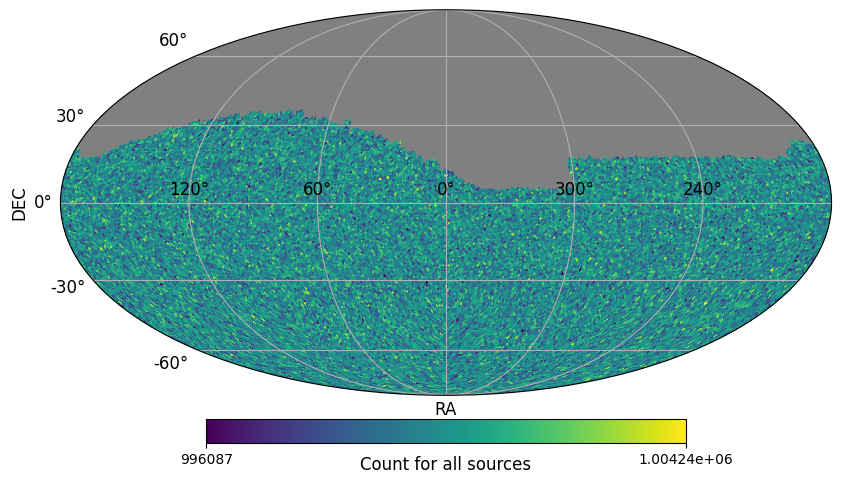

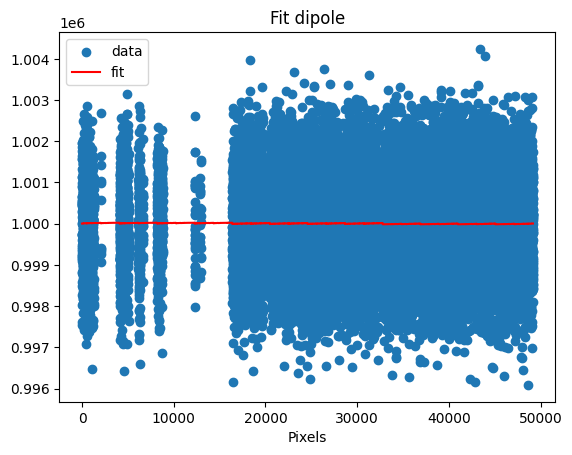

In [13]:
init =  (1e6, 0, 100, 40)
count_thMapper.fit_dipole("Masked", init)

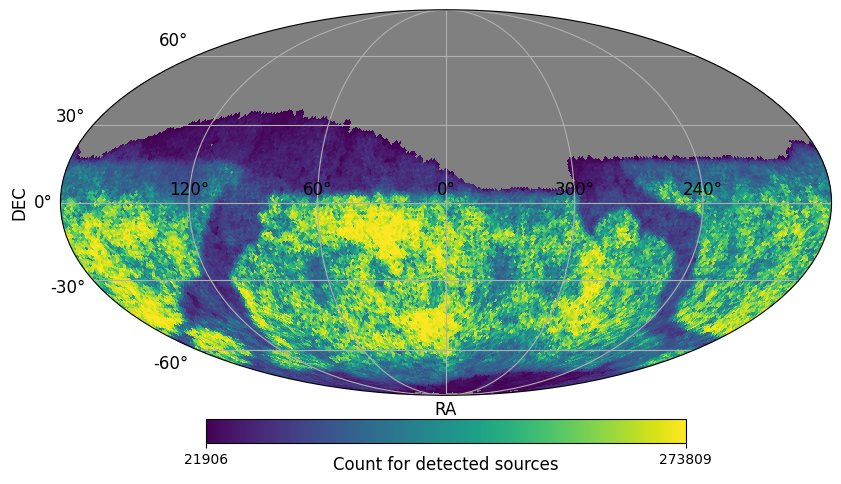

In [14]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "DetectMap_m5band_i")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.584e+08 (χ²/ndof = 9327.1)│              Nfcn = 395              │
│ EDM = 5.91e-05 (Goal: 0.0002)    │            time = 5.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │167.7188e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │331.468e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.119  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.678  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.65 -56.6567e-6      5.4e-3    4.212e-3 │
│   A │ -56.6567e-6    1.12e-09    -58.2e-9    -51.7e-9 │
│  ra │      5.4e-3    -58.2e-9    0.000385    0.001e-3 │
│ dec │    4.212e-3    -51.7e-9    0.001e-3    1.82e-05 │
└─────┴─────────────────────────────────────────────────┘

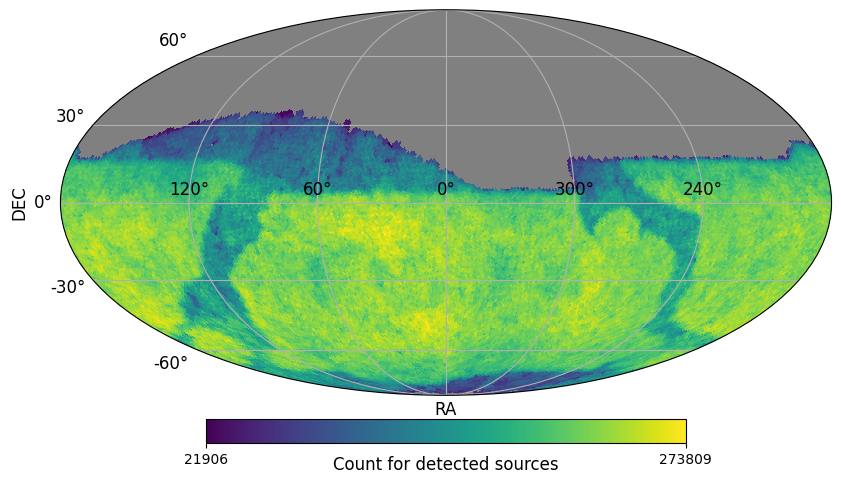

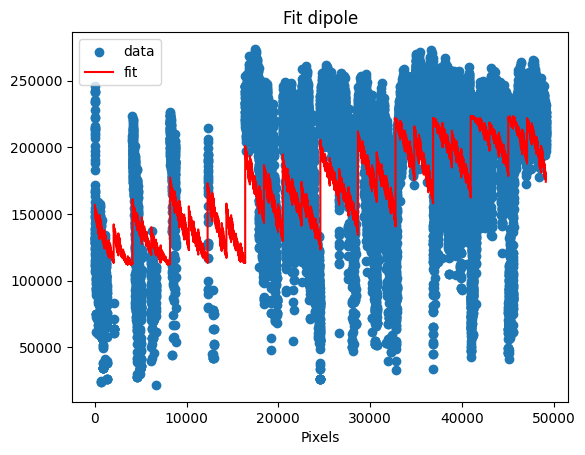

In [15]:
init =  (1e5, 1, 100, 40)
countDetectedMapper.fit_dipole("Masked", init)

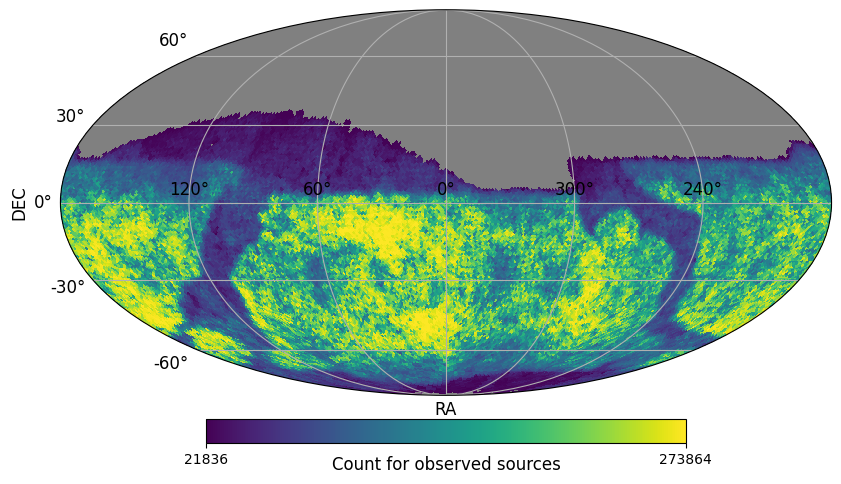

In [16]:
countObservedMapper = CountMapper.from_map(np.random.poisson(countDetectedMapper.map))
countObservedMapper._set_suffixTextPlot(unit = "observed sources")
countObservedMapper.set_mask(dm.m5iMasked.mask)
countObservedMapper.plot("Masked", norm='hist')

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "ObservMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.584e+08 (χ²/ndof = 9327.3)│              Nfcn = 404              │
│ EDM = 5.39e-05 (Goal: 0.0002)    │            time = 4.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │167.7177e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │331.496e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.155  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.680  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.65 -56.6569e-6      5.4e-3    4.212e-3 │
│   A │ -56.6569e-6    1.12e-09    -58.1e-9    -51.7e-9 │
│  ra │      5.4e-3    -58.1e-9    0.000385    0.001e-3 │
│ dec │    4.212e-3    -51.7e-9    0.001e-3    1.82e-05 │
└─────┴─────────────────────────────────────────────────┘

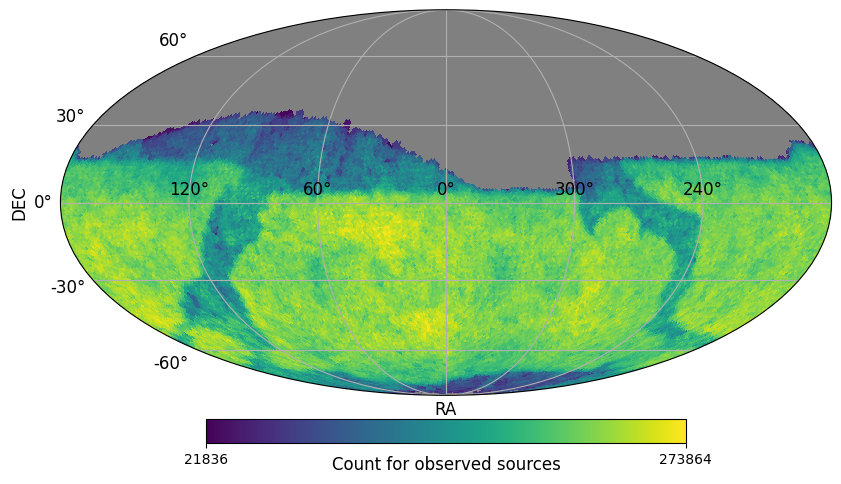

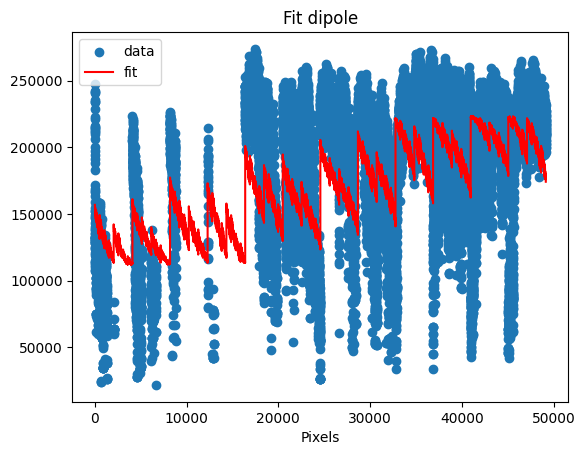

In [17]:
init =  (1e5, 1, 100, 40)
countObservedMapper.fit_dipole("Masked", init)

/tmp/ipykernel_55451/216236427.py:1: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


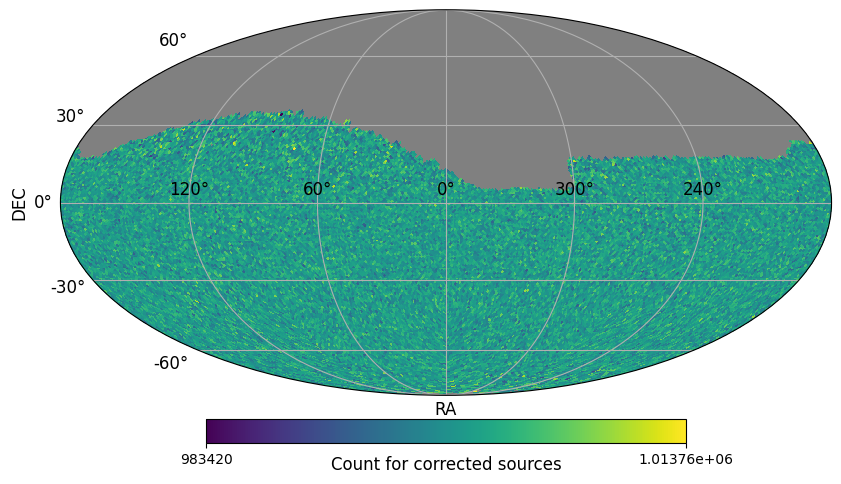

In [18]:
countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
countCorrectedMapper.fillna()
countCorrectedMapper._set_suffixTextPlot(unit = "corrected sources")
countCorrectedMapper.set_mask()
countCorrectedMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CorrectMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.18e+05 (χ²/ndof = 4.4)   │              Nfcn = 380              │
│ EDM = 1.13e-05 (Goal: 0.0002)    │            time = 4.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.996e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │   32e-6   │   10e-6   │   -9e-6    │   10e-6    │    0    │    1    │       │
│ 2 │ ra   │  0.11e-9  │3420469741.94e-9│  -0.12e-9  │3377456636.52e-9│    0    │   360   │       │
│ 3 │ dec  │    12     │    24     │    -25     │     23     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │   -9e-6   │   10e-6   │ -0.12e-9  │3377456636.52e-9│    -25    │    23     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        48.6 15.84420e-6   -536.7e-9         100 │
│   A │ 15.84420e-6     9.2e-11          -0 46.11891e-6 │
│  ra │   -536.7e-9          -0    1.57e-09   -640.9e-9 │
│ dec │         100 46.11891e-6   -640.9e-9         583 │
└─────┴─────────────────────────────────────────────────┘

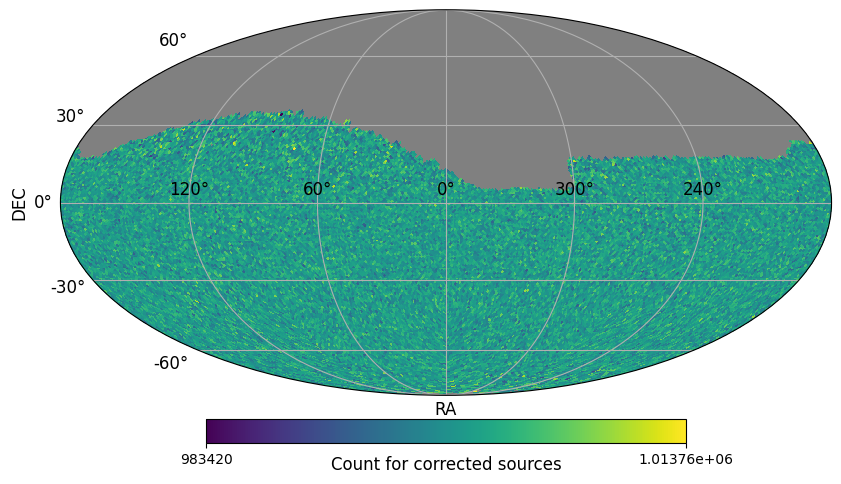

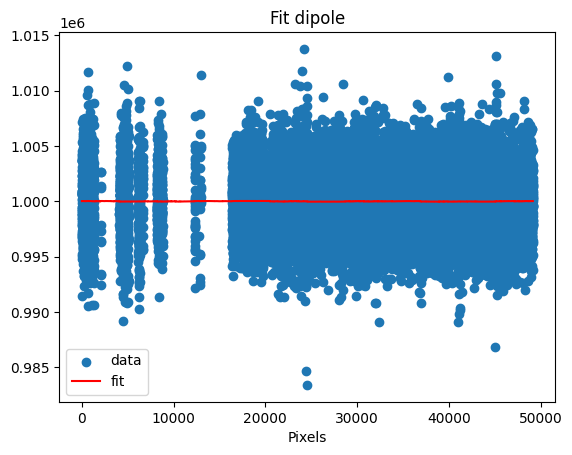

In [19]:
init =  (1e6, 0, 100, 40)
countCorrectedMapper.fit_dipole("Masked", init)

## Smoothing the map

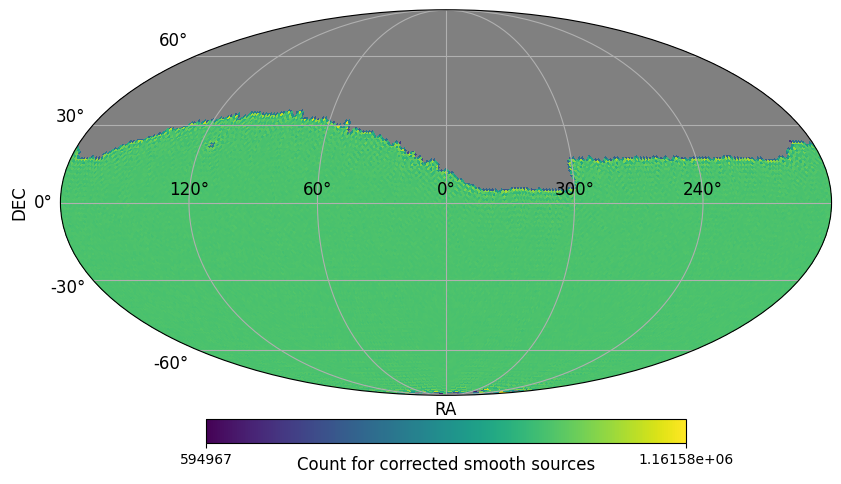

In [20]:
countSmoothMapper = CountMapper.from_map(hp.smoothing(countCorrectedMapper.map, nest=True, sigma=0.005))
countSmoothMapper._set_suffixTextPlot(unit = "corrected smooth sources")
countSmoothMapper.set_mask(countCorrectedMapper.mapMasked.mask)
countSmoothMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "SmoothMap_m5band_i_poissOnly")

## Reference spectrum

Intégrale du flux : 63.2951480487615


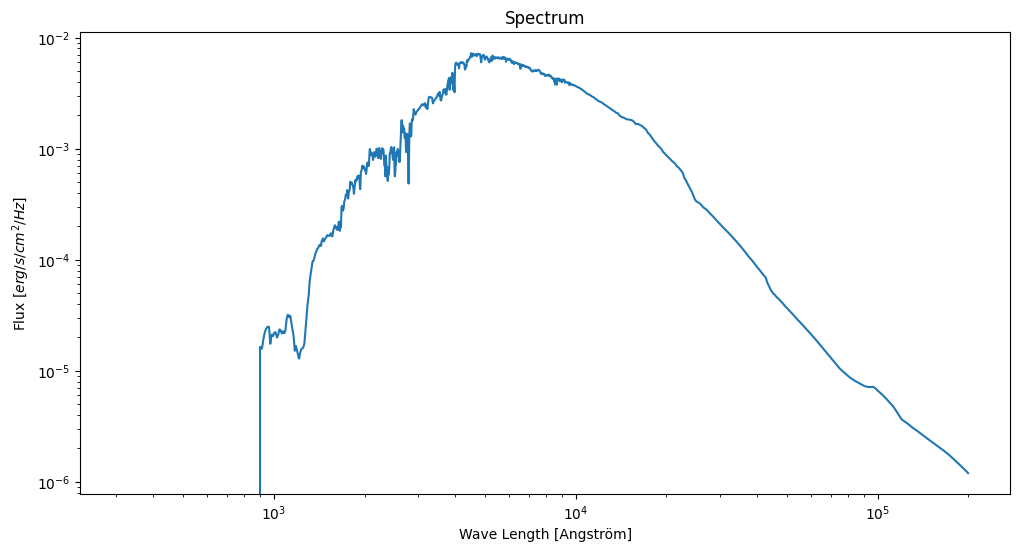

In [21]:
file = "../data/data SED/SED GAL/COSMOS/Ell1_A_0.sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot();

integral = np.trapz(refSpectum.flux, x=refSpectum.wavelength)
print(f"Intégrale du flux : {integral}")